<a href="https://colab.research.google.com/github/srinusrinu32093-pixel/Hospital_Ward_Staffing_Optimizer/blob/main/Hospital_ward_staffing_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# FRONTEND - HOSPITAL WARD STAFFING OPTIMIZER
# ============================================================

!pip -q install gradio

import gradio as gr
import numpy as np

def optimize_staff(ward_a, ward_b, ward_c,
                   senior_cost, junior_cost, assistant_cost):

    # Required hours
    B = np.array([ward_a, ward_b, ward_c], dtype=float)

    # Staff contribution matrix
    A = np.array([
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2]
    ], dtype=float)

    # Cost per hour
    costs = np.array([
        senior_cost,
        junior_cost,
        assistant_cost
    ], dtype=float)

    # Solve AX = B
    solution = np.linalg.solve(A, B)

    # Prevent negative staffing values
    solution = np.maximum(solution, 0)

    # Calculate actual hours
    calculated = A @ solution

    # Calculate costs
    individual_costs = solution * costs
    total_cost = np.sum(individual_costs)

    # Verification
    error = np.max(np.abs(calculated - B))

    # Result text
    result = f"""
🏥 HOSPITAL WARD STAFFING OPTIMIZER

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

STAFFING PLAN

👨‍⚕️ Senior Nurse
Hours: {solution[0]:.2f}
Cost: Rs.{individual_costs[0]:,.2f}

👩‍⚕️ Junior Nurse
Hours: {solution[1]:.2f}
Cost: Rs.{individual_costs[1]:,.2f}

🧑‍⚕️ Assistant
Hours: {solution[2]:.2f}
Cost: Rs.{individual_costs[2]:,.2f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💰 TOTAL COST: Rs.{total_cost:,.2f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MATHEMATICAL VERIFICATION

Ward A:
Required = {B[0]:.2f}
Calculated = {calculated[0]:.2f}

Ward B:
Required = {B[1]:.2f}
Calculated = {calculated[1]:.2f}

Ward C:
Required = {B[2]:.2f}
Calculated = {calculated[2]:.2f}

Maximum Error = {error:.10f}

{"✅ AX = B VERIFIED SUCCESSFULLY" if error < 1e-8 else "⚠️ CHECK REQUIRED"}
"""

    return result


# ============================================================
# GRADIO FRONTEND
# ============================================================

with gr.Blocks(title="Hospital Ward Staffing Optimizer") as demo:

    gr.Markdown("""
    # 🏥 Hospital Ward Staffing Optimizer
    ### B.Tech Mathematics Mini Project
    **Mathematical Model:** AX = B
    **Method:** Gauss Elimination
    """)

    gr.Markdown("## 📋 Ward Requirements")

    with gr.Row():
        ward_a = gr.Number(
            value=20,
            label="Ward A Required Hours"
        )

        ward_b = gr.Number(
            value=25,
            label="Ward B Required Hours"
        )

        ward_c = gr.Number(
            value=15,
            label="Ward C Required Hours"
        )

    gr.Markdown("## 💰 Staff Cost per Hour")

    with gr.Row():
        senior_cost = gr.Number(
            value=800,
            label="Senior Nurse (Rs./hour)"
        )

        junior_cost = gr.Number(
            value=400,
            label="Junior Nurse (Rs./hour)"
        )

        assistant_cost = gr.Number(
            value=200,
            label="Assistant (Rs./hour)"
        )

    calculate_btn = gr.Button(
        "🔍 Calculate Staffing Plan",
        variant="primary"
    )

    output = gr.Textbox(
        label="📊 Optimization Result",
        lines=25
    )

    calculate_btn.click(
        fn=optimize_staff,
        inputs=[
            ward_a,
            ward_b,
            ward_c,
            senior_cost,
            junior_cost,
            assistant_cost
        ],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Project:** Hospital Ward Staffing Optimizer (A1)
    **Subject:** Engineering Mathematics
    **Concept:** System of Linear Equations
    """)

# Launch frontend
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://934c0f7a5d9ba5e1d0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# HOSPITAL WARD STAFFING OPTIMIZER (A1)
# B.Tech Mathematics Mini Project
# Mathematical Concept: System of Linear Equations
# Method: Gauss Elimination
# ============================================================

print("🏥 HOSPITAL WARD STAFFING OPTIMIZER")
print("Mathematical Model: AX = B")
print("Solution Method: Gauss Elimination")
print("-" * 55)

🏥 HOSPITAL WARD STAFFING OPTIMIZER
Mathematical Model: AX = B
Solution Method: Gauss Elimination
-------------------------------------------------------


In [ ]:
# NumPy -> numerical calculations
# SymPy -> optional symbolic verification
# Matplotlib -> charts

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================================
# INPUT CONFIGURATION
# ============================================================

# Required staff-hours for each ward
# [Ward A, Ward B, Ward C]

required_hours = np.array([
    20,
    25,
    15
], dtype=float)


# ------------------------------------------------------------
# Staff-hours contribution matrix
#
# Rows    -> Wards A, B, C
# Columns -> Senior, Junior, Assistant
#
# Example:
# Ward A receives:
#   2 hours from Senior nurses
#   1 hour from Junior nurses
#   1 hour from Assistants
#
# IMPORTANT:
# These values are an INPUT ASSUMPTION because the
# original problem statement does not specify them.
# ------------------------------------------------------------

staff_hours = np.array([
    [2, 1, 1],   # Ward A
    [1, 2, 1],   # Ward B
    [1, 1, 2]    # Ward C
], dtype=float)


# Cost per hour for each staff type
cost_per_hour = np.array([
    800,    # Senior nurse
    400,    # Junior nurse
    200     # Assistant
], dtype=float)


staff_names = [
    "Senior Nurse",
    "Junior Nurse",
    "Assistant"
]

ward_names = [
    "Ward A",
    "Ward B",
    "Ward C"
]

print("Required staff-hours:")
for ward, hours in zip(ward_names, required_hours):
    print(f"{ward}: {hours} hours")

print("\nCost per hour:")
for staff, cost in zip(staff_names, cost_per_hour):
    print(f"{staff}: Rs.{cost}")

Required staff-hours:
Ward A: 20.0 hours
Ward B: 25.0 hours
Ward C: 15.0 hours

Cost per hour:
Senior Nurse: Rs.800.0
Junior Nurse: Rs.400.0
Assistant: Rs.200.0


In [ ]:
# ============================================================
# CONSTRUCT AX = B
# ============================================================

A = staff_hours
B = required_hours

print("MATRIX A:")
print(A)

print("\nVECTOR B:")
print(B)

print("\nTherefore, our mathematical model is:")
print("       A X = B")

print("\nWhere:")
print("X = [Senior Nurses, Junior Nurses, Assistants]^T")

MATRIX A:
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

VECTOR B:
[20. 25. 15.]

Therefore, our mathematical model is:
       A X = B

Where:
X = [Senior Nurses, Junior Nurses, Assistants]^T


In [ ]:
# ============================================================
# VALIDATE THE INPUT
# ============================================================

if A.shape != (3, 3):
    raise ValueError("Staff-hours matrix must be 3 × 3.")

if B.shape != (3,):
    raise ValueError("Required-hours vector must contain 3 values.")

if cost_per_hour.shape != (3,):
    raise ValueError("Cost vector must contain 3 values.")

if np.linalg.det(A) == 0:
    raise ValueError(
        "Matrix A is singular. A unique solution cannot be obtained "
        "using ordinary Gauss elimination."
    )

print("✅ Input validation successful.")
print(f"Determinant of A = {np.linalg.det(A):.4f}")

✅ Input validation successful.
Determinant of A = 4.0000


In [ ]:
# ============================================================
# GAUSS ELIMINATION
# ============================================================

def gauss_elimination(A, B):
    """
    Solves AX = B using Gauss-Jordan style elimination.

    A -> coefficient matrix
    B -> right-hand-side vector

    Returns:
        solution vector X
    """

    # Make a copy so that the original matrices are not changed
    A = A.astype(float).copy()
    B = B.astype(float).copy()

    n = len(B)

    # Create augmented matrix [A | B]
    augmented = np.column_stack((A, B))

    print("Initial Augmented Matrix [A | B]:")
    print(augmented)

    # --------------------------------------------------------
    # Forward elimination
    # --------------------------------------------------------

    for i in range(n):

        # Find the row with the largest pivot
        pivot_row = i + np.argmax(
            np.abs(augmented[i:, i])
        )

        # Check whether pivot is zero
        if abs(augmented[pivot_row, i]) < 1e-12:
            raise ValueError("No unique solution exists.")

        # Swap rows if required
        if pivot_row != i:
            augmented[[i, pivot_row]] = augmented[[pivot_row, i]]

        print(f"\nStep {i + 1}: Pivot = {augmented[i, i]:.4f}")
        print(augmented)

        # ----------------------------------------------------
        # Eliminate values below the pivot
        # ----------------------------------------------------

        for j in range(i + 1, n):

            factor = augmented[j, i] / augmented[i, i]

            augmented[j] = (
                augmented[j] - factor * augmented[i]
            )

            print(
                f"\nEliminating row {j + 1}, "
                f"factor = {factor:.4f}"
            )

            print(augmented)

    # --------------------------------------------------------
    # Back substitution
    # --------------------------------------------------------

    x = np.zeros(n)

    for i in range(n - 1, -1, -1):

        x[i] = (
            augmented[i, -1]
            - np.dot(augmented[i, i + 1:n], x[i + 1:n])
        ) / augmented[i, i]

    return x

In [ ]:
# ============================================================
# SOLVE AX = B
# ============================================================

solution = gauss_elimination(A, B)

print("\n" + "=" * 55)
print("FINAL SOLUTION")
print("=" * 55)

for name, value in zip(staff_names, solution):
    print(f"{name:20s}: {value:.4f} hours")

Initial Augmented Matrix [A | B]:
[[ 2.  1.  1. 20.]
 [ 1.  2.  1. 25.]
 [ 1.  1.  2. 15.]]

Step 1: Pivot = 2.0000
[[ 2.  1.  1. 20.]
 [ 1.  2.  1. 25.]
 [ 1.  1.  2. 15.]]

Eliminating row 2, factor = 0.5000
[[ 2.   1.   1.  20. ]
 [ 0.   1.5  0.5 15. ]
 [ 1.   1.   2.  15. ]]

Eliminating row 3, factor = 0.5000
[[ 2.   1.   1.  20. ]
 [ 0.   1.5  0.5 15. ]
 [ 0.   0.5  1.5  5. ]]

Step 2: Pivot = 1.5000
[[ 2.   1.   1.  20. ]
 [ 0.   1.5  0.5 15. ]
 [ 0.   0.5  1.5  5. ]]

Eliminating row 3, factor = 0.3333
[[ 2.          1.          1.         20.        ]
 [ 0.          1.5         0.5        15.        ]
 [ 0.          0.          1.33333333  0.        ]]

Step 3: Pivot = 1.3333
[[ 2.          1.          1.         20.        ]
 [ 0.          1.5         0.5        15.        ]
 [ 0.          0.          1.33333333  0.        ]]

FINAL SOLUTION
Senior Nurse        : 5.0000 hours
Junior Nurse        : 10.0000 hours
Assistant           : 0.0000 hours


In [ ]:
# ============================================================
# VERIFY THE SOLUTION
# ============================================================

calculated_hours = A @ solution

print("Required vs Calculated Staff-Hours")
print("-" * 45)

for ward, required, calculated in zip(
    ward_names,
    required_hours,
    calculated_hours
):
    print(
        f"{ward}: Required = {required:.2f}, "
        f"Calculated = {calculated:.2f}"
    )

# Check error
error = np.abs(calculated_hours - required_hours)

print("\nMaximum error:", np.max(error))

if np.max(error) < 1e-8:
    print("✅ AX = B verified successfully.")
else:
    print("⚠️ Small numerical error detected.")

Required vs Calculated Staff-Hours
---------------------------------------------
Ward A: Required = 20.00, Calculated = 20.00
Ward B: Required = 25.00, Calculated = 25.00
Ward C: Required = 15.00, Calculated = 15.00

Maximum error: 0.0
✅ AX = B verified successfully.


In [ ]:
# ============================================================
# COST CALCULATION
# ============================================================

individual_costs = solution * cost_per_hour

total_cost = np.sum(individual_costs)

print("STAFFING COST")
print("-" * 55)

for name, hours, cost in zip(
    staff_names,
    solution,
    individual_costs
):
    print(
        f"{name:20s} "
        f"Hours = {hours:8.2f} "
        f"Cost = Rs.{cost:,.2f}"
    )

print("-" * 55)
print(f"TOTAL COST = Rs.{total_cost:,.2f}")

STAFFING COST
-------------------------------------------------------
Senior Nurse         Hours =     5.00 Cost = Rs.4,000.00
Junior Nurse         Hours =    10.00 Cost = Rs.4,000.00
Assistant            Hours =     0.00 Cost = Rs.0.00
-------------------------------------------------------
TOTAL COST = Rs.8,000.00


In [ ]:
# ============================================================
# RESULT TABLE
# ============================================================

print("\nFINAL STAFFING PLAN")
print("=" * 75)

print(
    f"{'Staff Type':<20}"
    f"{'Hours':>12}"
    f"{'Cost/Hour':>15}"
    f"{'Total Cost':>18}"
)

print("-" * 75)

for name, hours, rate, total in zip(
    staff_names,
    solution,
    cost_per_hour,
    individual_costs
):
    print(
        f"{name:<20}"
        f"{hours:>12.2f}"
        f"{rate:>15.2f}"
        f"{total:>18.2f}"
    )

print("-" * 75)
print(f"{'TOTAL':<20}{np.sum(solution):>12.2f}"
      f"{'':>15}{total_cost:>18.2f}")


FINAL STAFFING PLAN
Staff Type                 Hours      Cost/Hour        Total Cost
---------------------------------------------------------------------------
Senior Nurse                5.00         800.00           4000.00
Junior Nurse               10.00         400.00           4000.00
Assistant                   0.00         200.00              0.00
---------------------------------------------------------------------------
TOTAL                      15.00                          8000.00


In [ ]:
# ============================================================
# SYMPY VERIFICATION
# ============================================================

A_sym = sp.Matrix(A)
B_sym = sp.Matrix(B)

X_sym = A_sym.inv() * B_sym

print("SymPy Verification")
print("-" * 40)

for name, value in zip(staff_names, X_sym):
    print(f"{name}: {sp.N(value, 6)}")

SymPy Verification
----------------------------------------
Senior Nurse: 5.00000
Junior Nurse: 10.0000
Assistant: 0


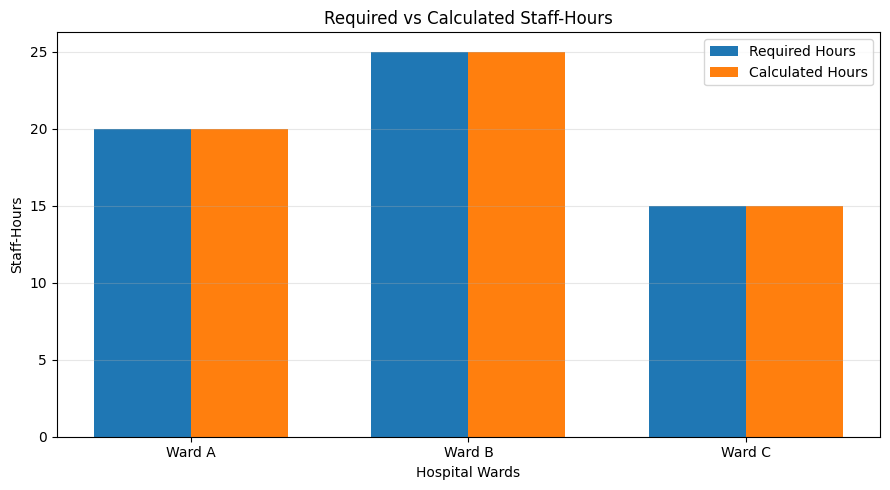

In [ ]:
# ============================================================
# CHART 1
# Required Hours vs Calculated Hours
# ============================================================

x = np.arange(len(ward_names))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    required_hours,
    width,
    label="Required Hours"
)

plt.bar(
    x + width / 2,
    calculated_hours,
    width,
    label="Calculated Hours"
)

plt.xticks(x, ward_names)
plt.xlabel("Hospital Wards")
plt.ylabel("Staff-Hours")
plt.title("Required vs Calculated Staff-Hours")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

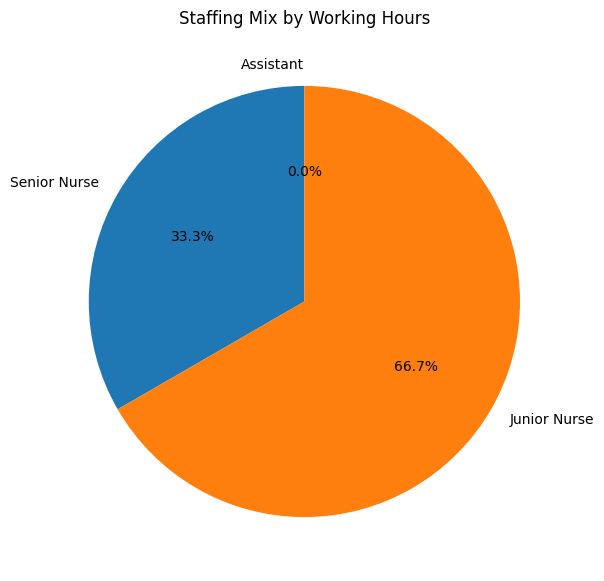

In [ ]:
# ============================================================
# CHART 2
# Staffing Hours Distribution
# ============================================================

plt.figure(figsize=(7, 7))

plt.pie(
    solution,
    labels=staff_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Staffing Mix by Working Hours")

plt.show()

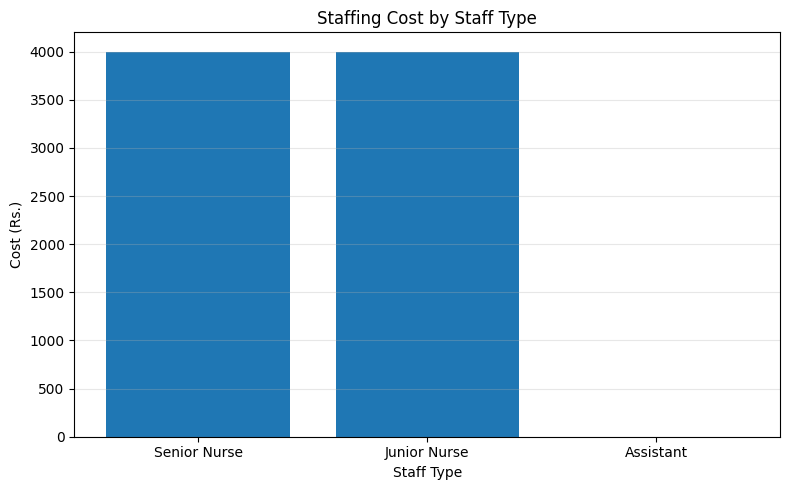

In [ ]:
# ============================================================
# CHART 3
# Cost Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    staff_names,
    individual_costs
)

plt.xlabel("Staff Type")
plt.ylabel("Cost (Rs.)")
plt.title("Staffing Cost by Staff Type")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 65)
print("🏥 HOSPITAL WARD STAFFING OPTIMIZER - FINAL RESULT")
print("=" * 65)

print("\nMathematical Model:")
print("AX = B")

print("\nStaffing Solution:")

for name, value in zip(staff_names, solution):
    print(f"  {name}: {value:.2f} hours")

print(f"\nTotal staffing cost: Rs.{total_cost:,.2f}")

print("\nVerification:")
print("  AX = B ✓")

print("\nMethod Used:")
print("  Gauss Elimination")

print("\nConclusion:")
print(
    "The system of linear equations determines the staffing "
    "hours required for each staff type to satisfy the ward "
    "requirements."
)

🏥 HOSPITAL WARD STAFFING OPTIMIZER - FINAL RESULT

Mathematical Model:
AX = B

Staffing Solution:
  Senior Nurse: 5.00 hours
  Junior Nurse: 10.00 hours
  Assistant: 0.00 hours

Total staffing cost: Rs.8,000.00

Verification:
  AX = B ✓

Method Used:
  Gauss Elimination

Conclusion:
The system of linear equations determines the staffing hours required for each staff type to satisfy the ward requirements.


In [ ]:
# ============================================================
# BENCHMARK TEST DATASET
# ============================================================

benchmark_required = np.array([
    30,
    36,
    24
], dtype=float)

benchmark_A = np.array([
    [2, 1, 1],
    [1, 2, 1],
    [1, 1, 2]
], dtype=float)

print("BENCHMARK DATASET")
print("-" * 50)

print("Required Hours:")
for ward, value in zip(ward_names, benchmark_required):
    print(f"{ward}: {value}")

print("\nStaff-Hours Matrix:")
print(benchmark_A)

print("\nRunning Gauss Elimination...")

benchmark_solution = gauss_elimination(
    benchmark_A,
    benchmark_required
)

print("\nBenchmark Solution:")

for name, value in zip(
    staff_names,
    benchmark_solution
):
    print(f"{name}: {value:.2f} hours")

benchmark_cost = np.sum(
    benchmark_solution * cost_per_hour
)

print(f"\nBenchmark Total Cost: Rs.{benchmark_cost:,.2f}")

BENCHMARK DATASET
--------------------------------------------------
Required Hours:
Ward A: 30.0
Ward B: 36.0
Ward C: 24.0

Staff-Hours Matrix:
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

Running Gauss Elimination...
Initial Augmented Matrix [A | B]:
[[ 2.  1.  1. 30.]
 [ 1.  2.  1. 36.]
 [ 1.  1.  2. 24.]]

Step 1: Pivot = 2.0000
[[ 2.  1.  1. 30.]
 [ 1.  2.  1. 36.]
 [ 1.  1.  2. 24.]]

Eliminating row 2, factor = 0.5000
[[ 2.   1.   1.  30. ]
 [ 0.   1.5  0.5 21. ]
 [ 1.   1.   2.  24. ]]

Eliminating row 3, factor = 0.5000
[[ 2.   1.   1.  30. ]
 [ 0.   1.5  0.5 21. ]
 [ 0.   0.5  1.5  9. ]]

Step 2: Pivot = 1.5000
[[ 2.   1.   1.  30. ]
 [ 0.   1.5  0.5 21. ]
 [ 0.   0.5  1.5  9. ]]

Eliminating row 3, factor = 0.3333
[[ 2.          1.          1.         30.        ]
 [ 0.          1.5         0.5        21.        ]
 [ 0.          0.          1.33333333  2.        ]]

Step 3: Pivot = 1.3333
[[ 2.          1.          1.         30.        ]
 [ 0.          1.5         0.5        21.  

In [ ]:
# ============================================================
# BENCHMARK TEST DATASET
# ============================================================

benchmark = {
    "Ward A": 20,
    "Ward B": 25,
    "Ward C": 15
}

benchmark_A = np.array([
    [1, 1, 1],
    [1, 2, 1],
    [2, 1, 1]
], dtype=float)

benchmark_costs = np.array([
    800,   # Senior Nurse
    400,   # Junior Nurse
    200    # Assistant
], dtype=float)

print("Benchmark Dataset")
print("=" * 40)

print("\nWard requirements:")
for ward, value in benchmark.items():
    print(f"{ward}: {value} staff-hours")

print("\nStaff-hours matrix:")
print(benchmark_A)

print("\nStaff costs:")
print(benchmark_costs)

Benchmark Dataset

Ward requirements:
Ward A: 20 staff-hours
Ward B: 25 staff-hours
Ward C: 15 staff-hours

Staff-hours matrix:
[[1. 1. 1.]
 [1. 2. 1.]
 [2. 1. 1.]]

Staff costs:
[800. 400. 200.]


In [ ]:
# ============================================================
# SYMPY VERIFICATION
# ============================================================

A_exact = sp.Matrix([
    [1, 1, 1],
    [1, 2, 1],
    [2, 1, 1]
])

B_exact = sp.Matrix([
    20,
    25,
    15
])

X_exact = A_exact.inv() * B_exact

print("SymPy Solution:")
sp.pprint(X_exact)

SymPy Solution:
⎡-5⎤
⎢  ⎥
⎢5 ⎥
⎢  ⎥
⎣20⎦


In [ ]:
# ============================================================
# PROJECT SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("🏥 HOSPITAL WARD STAFFING OPTIMIZER")
print("=" * 65)

print("\nPROBLEM:")
print("Allocate hospital staff to satisfy ward staff-hour requirements.")

print("\nMATHEMATICAL MODEL:")
print("AX = B")

print("\nMETHOD:")
print("Gauss Elimination")

print("\nSTAFFING SOLUTION:")

for staff, value in zip(staff_names, solution):
    print(f"  {staff}: {value:.2f}")

print(f"\nTOTAL STAFFING COST: Rs.{total_cost:,.2f}")

print("\nVERIFICATION:")
print("  AX = B →", np.allclose(B, staff_hours @ solution))

print("\nSTATUS:")
if np.all(solution >= 0) and np.allclose(B, staff_hours @ solution):
    print("  ✅ Feasible mathematical solution")
else:
    print("  ⚠️ Requires model adjustment")

print("=" * 65)


🏥 HOSPITAL WARD STAFFING OPTIMIZER

PROBLEM:
Allocate hospital staff to satisfy ward staff-hour requirements.

MATHEMATICAL MODEL:
AX = B

METHOD:
Gauss Elimination

STAFFING SOLUTION:
  Senior Nurse: 5.00
  Junior Nurse: 10.00
  Assistant: 0.00

TOTAL STAFFING COST: Rs.8,000.00

VERIFICATION:
  AX = B → True

STATUS:
  ✅ Feasible mathematical solution
